# 07 — OE Image Inversion with Dask

This notebook demonstrates OE-based image inversion using `dask_oe_engine`.  
It uses the same Sentinel-2 Wadden Sea dataset as NB04, but replaces the
lmfit pixel-by-pixel loop with JAX-vmapped Gauss-Newton OE — providing
not just retrieved parameters but also **uncertainty maps** (posterior σ),
**averaging kernel maps** (how data-driven each pixel is), and a
**chi-squared map** (goodness of fit).

Key differences vs NB04:
- Forward model: `albert_mobley_jax` (JAX, exact Jacobians) instead of `albert_mobley` (lmfit)
- Retrieved params: C_0, C_Y, C_Mie, zB (vs. zB only in NB04)
- Bottom: per-tile mean of low-tide image, rebuilt per Dask tile (same spirit as NB04)
- Outputs: xarray Dataset with x_hat, σ, A_diag, chi² per pixel

In [1]:
import os
import numpy as np
import xarray as xr
import lmfit
import dask
import matplotlib.pyplot as plt
import jax.numpy as jnp
import cmocean.cm as cm

from bio_optics.inversion import oe_engine, dask_oe_engine
from bio_optics.water.reflectance import albert_mobley_jax

## Get data

Same Sentinel-2 Wadden Sea scene as NB04: two time steps at the same location.
Time 0 = low tide (benthic reflectance visible), Time 1 = high tide (water-leaving Rrs).

In [2]:
dataset = xr.open_dataset(os.path.join(os.getcwd(), 'example_data/S2L2A_example.nc'))
dataset

<xarray.Dataset> Size: 8MB
Dimensions:      (time: 2, x: 449, y: 267)
Coordinates:
  * time         (time) datetime64[ns] 16B 2023-09-06T10:35:55 2023-09-11T10:...
  * x            (x) float64 4kB 4.761e+05 4.761e+05 ... 4.806e+05 4.806e+05
  * y            (y) float64 2kB 6.05e+06 6.05e+06 ... 6.047e+06 6.047e+06
    spatial_ref  int32 4B ...
Data variables:
    crs          int32 4B ...
    B02          (time, y, x) float32 959kB ...
    B03          (time, y, x) float32 959kB ...
    B04          (time, y, x) float32 959kB ...
    B05          (time, y, x) float32 959kB ...
    B06          (time, y, x) float32 959kB ...
    B07          (time, y, x) float32 959kB ...
    B08          (time, y, x) float32 959kB ...
    B8A          (time, y, x) float32 959kB ...
Attributes:
    Conventions:             CF-1.7
    date_created:            2024-06-10T12:36:20.350532
    processing_level:        L2A
    time_coverage_duration:  P4DT23H59M59S
    time_coverage_end:       2023-09-11T10:35:54+00:00
    time_coverage_start:     2023-09-06T10:35:55+00:00
    title:                   S2L2A Data Cube Subset

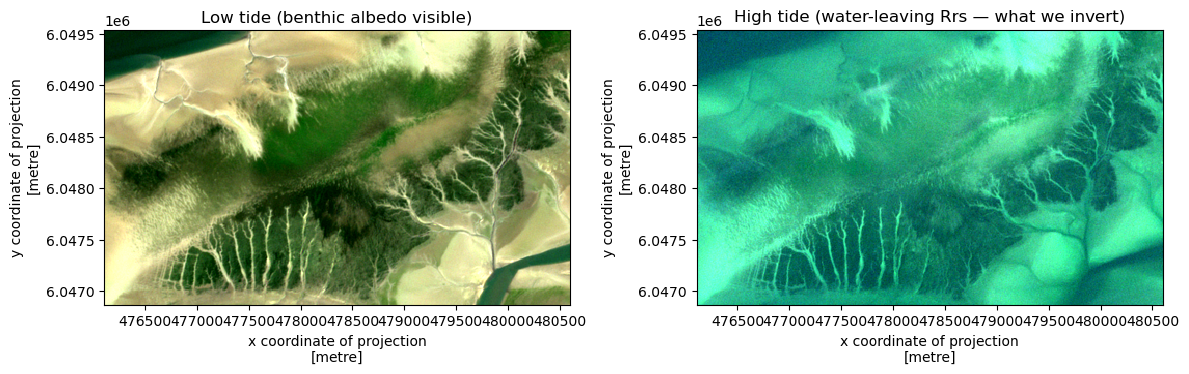

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dataset[['B04', 'B03', 'B02']].isel(time=0).to_array().plot.imshow(robust=True, ax=axes[0])
axes[0].set_title('Low tide (benthic albedo visible)')
dataset[['B04', 'B03', 'B02']].isel(time=1).to_array().plot.imshow(robust=True, ax=axes[1])
axes[1].set_title('High tide (water-leaving Rrs — what we invert)')
plt.tight_layout()
plt.show()

## Prepare arrays

- `Rrs_image`: high-tide reflectance divided by π → Rrs [sr⁻¹], shape (n_rows, n_cols, n_obs)
- `albedo_image`: low-tide reflectance **not** divided by π → albedo [dimensionless],
  used as per-tile bottom input (same convention as NB04).

In [4]:
wavelengths = np.array([490, 560, 665, 705, 740, 783, 842, 865])

band_vars = list(dataset.data_vars)[1:]   # skip the first variable (time or similar)

# --- detect spatial dimension names and order from the dataset ---------------
# The dataset may store bands as (x, y) or (y, x); we must preserve that order
# when stacking so that the reshape after inversion is consistent.
ref_band = dataset.isel(time=1)[band_vars[0]]
spatial_dim_names = list(ref_band.dims)          # e.g. ['x', 'y'] or ['y', 'x']
print('Spatial dims in dataset:', spatial_dim_names)

# Extract spatial coordinates for correct plot orientation later
spatial_coords = {d: dataset[d].values for d in spatial_dim_names if d in dataset.coords}

# --- stack bands (bands last, spatial dims in dataset-native order) ----------
Rrs_image = np.stack(
    [dataset.isel(time=1)[v].values for v in band_vars], axis=-1
) / np.pi
print('Rrs_image shape:', Rrs_image.shape)    # (dim0, dim1, n_obs)

albedo_image = np.stack(
    [dataset.isel(time=0)[v].values for v in band_vars], axis=-1
)
print('albedo_image shape:', albedo_image.shape)

Spatial dims in dataset: ['y', 'x']
Rrs_image shape: (267, 449, 8)
albedo_image shape: (267, 449, 8)


## Precompute

Run the spectral lookup table resampling once. We do **not** insert the bottom
albedo here — it will be inserted per tile during inversion, giving each tile its
own representative bottom spectrum (tile mean of the low-tide image).

In [5]:
pre_base = albert_mobley_jax.precompute(wavelengths)
print('precomputed keys:', list(pre_base.keys()))

precomputed keys: ['wavelengths', 'a_w', 'da_w_div_dT', 'a_i_spec', 'b_phy_norm', 'bb_w', 'b_X_norm', 'R_b_i']


## Configuration

Edit **only this cell** to change which parameters are retrieved and with what priors.

| Key | Meaning |
|---|---|
| `vary` | `True` = free parameter (retrieved), `False` = fixed at `value` |
| `value` | Initial / fixed value in physical units |
| `sigma_a` | Prior uncertainty in retrieval space: fractional for log-params (0.7 ≈ ×2), physical std for linear params |
| `log` | `True` = retrieve in log-space (recommended for strictly positive quantities) |

**Optional softmax bottom mixing:** Add `f_mix_0`, `f_mix_1`, … entries to `fit_config` to retrieve
benthic type fractions via a softmax parameterization. The N free logits plus a reference logit (fixed at 0)
yield N+1 non-negative fractions that sum to 1. Set `log=False` for logit parameters; `sigma_a` is in logit
units (2.0 ≈ factor-of-7 prior range in fraction space).

In [6]:
# ── Retrieval configuration — edit here only ─────────────────────────────────
fit_config = {
    'C_0':   dict(vary=False, value=0.5,  sigma_a=1.0, log=True),   # chl [mg/m³]
    'C_Y':   dict(vary=False, value=0.1,  sigma_a=1.0, log=True),   # CDOM [1/m]
    'C_Mie': dict(vary=False, value=0.1,  sigma_a=1.0, log=True),   # SPM [g/m³]
    'zB':    dict(vary=True,  value=0.5,  sigma_a=0.7, log=True),   # depth [m]
    # Optional softmax bottom mixing — add f_mix_N entries to retrieve benthic fractions.
    # N free logits are fitted; a (N+1)-th reference type has logit fixed at 0.
    # Example: uncomment below to retrieve mixing between bottom types 0 and 1 (+ type 2 as reference):
    # 'f_mix_0': dict(vary=True, value=0.0, sigma_a=2.0, log=False),  # logit for type 0
    # 'f_mix_1': dict(vary=True, value=0.0, sigma_a=2.0, log=False),  # logit for type 1
}

noise     = 0.005   # measurement std [sr⁻¹]
n_iter    = 15
tile_size = 4096    # pixels per Dask tile

# ── Plot metadata for all possible parameters (label, unit, colormap) ─────────
PARAM_META = {
    'C_0':   ('Chlorophyll C₀', 'mg m⁻³', 'Greens'),
    'C_Y':   ('CDOM C_Y',       'm⁻¹',    'YlOrBr'),
    'C_Mie': ('SPM C_Mie',      'g m⁻³',  'Oranges'),
    'zB':    ('Depth z_B',      'm',       cm.deep),
}

# ── Derived — no edits needed below ──────────────────────────────────────────
params = lmfit.Parameters()

# Geometry
params.add('theta_sun',  value=np.radians(30), vary=False)
params.add('theta_view', value=np.radians(0),  vary=False)
params.add('n1',         value=1.0,            vary=False)
params.add('n2',         value=1.33,           vary=False)
params.add('kappa_0',    value=1.0546,         vary=False)

# Water constituents (vary/value set from fit_config below)
params.add('C_0',   value=fit_config['C_0']['value'],   vary=fit_config['C_0']['vary'])
params.add('C_Y',   value=fit_config['C_Y']['value'],   vary=fit_config['C_Y']['vary'])
params.add('C_Mie', value=fit_config['C_Mie']['value'], vary=fit_config['C_Mie']['vary'])
params.add('C_1',   value=0.0, vary=False)
params.add('C_2',   value=0.0, vary=False)
params.add('C_3',   value=0.0, vary=False)
params.add('C_4',   value=0.0, vary=False)
params.add('C_5',   value=0.0, vary=False)
params.add('C_X',   value=0.0, vary=False)

# IOP parameters
params.add('S',                   value=0.014,  vary=False)
params.add('S_NAP',               value=0.011,  vary=False)
params.add('lambda_0',            value=440.0,  vary=False)
params.add('K',                   value=0.0,    vary=False)
params.add('T_W',                 value=18.0,   vary=False)
params.add('T_W_0',               value=20.0,   vary=False)
params.add('a_NAP_spec_lambda_0', value=0.041,  vary=False)
params.add('bb_phy_spec',         value=0.0010, vary=False)
params.add('bb_Mie_spec',         value=0.0042, vary=False)
params.add('bb_X_spec',           value=0.0086, vary=False)
params.add('lambda_S',            value=500.0,  vary=False)
params.add('n',                   value=-1.0,   vary=False)

# Bottom (100% first type = measured albedo inserted via aux_image)
for i in range(6):
    params.add(f'f_{i}', value=1.0 if i == 0 else 0.0, vary=False)
    params.add(f'B_{i}', value=1/np.pi, vary=False)

# Optional softmax bottom mixing — add f_mix_* from fit_config if present
for name in sorted(n for n in fit_config if n.startswith('f_mix_')):
    params.add(name, value=fit_config[name]['value'], vary=fit_config[name]['vary'])
    idx = name.split('_')[-1]
    PARAM_META[name] = (f'Bottom mix logit {idx}', 'logit', 'RdYlGn')

# Depth
params.add('zB', value=fit_config['zB']['value'], vary=fit_config['zB']['vary'])

# OE prior derived from fit_config
sigma_a    = {n: c['sigma_a'] for n, c in fit_config.items() if c['vary']}
log_params = [n for n, c in fit_config.items() if c['vary'] and c['log']]

print('Free parameters:', [n for n in params if params[n].vary])
print('log_params:',       log_params)
print('sigma_a:',          sigma_a)

Free parameters: ['zB']
log_params: ['zB']
sigma_a: {'zB': 0.7}


## Run inversion

Build one forward function and `InversionSetup` for the whole image.  
Per-pixel bottom reflectance is passed as `aux_image={'R_b_i': R_b_i_image}` — 
no per-tile rebuild of `f_fit`, no JIT recompilation per tile.

`dask_oe_engine.invert_image` slices `aux_image` per tile and calls
`f_fit(x, aux)` for each pixel, where `aux` overrides the `R_b_i` entry
in the precomputed spectral tables.

In [7]:
all_names = list(params.keys())

# Build one forward function and setup for the whole image
f_vec = albert_mobley_jax.make_forward_vec(all_names, pre_base)
setup = oe_engine.build_inversion(params, f_vec, sigma_a, log_params=log_params)

# Per-pixel bottom: start from precomputed default, set first type = measured albedo
R_b_i_base  = np.array(pre_base['R_b_i'])                               # (n_obs, 6)
R_b_i_image = np.tile(R_b_i_base, (*Rrs_image.shape[:2], 1, 1))        # (n_dim0, n_dim1, n_obs, 6)
R_b_i_image[..., 0] = albedo_image                                       # per-pixel first bottom type

print('R_b_i_image shape:', R_b_i_image.shape)
print(f'Running inversion — {Rrs_image.shape[0]*Rrs_image.shape[1]} pixels, tile_size={tile_size}...')

results = dask_oe_engine.invert_image(
    Rrs_image, setup, noise,
    n_iter=n_iter,
    tile_size=tile_size,
    aux_image={'R_b_i': R_b_i_image},
)
print('Done.')

R_b_i_image shape: (267, 449, 8, 6)
Running inversion — 119883 pixels, tile_size=4096...
Done.


In [8]:
ds = dask_oe_engine.to_dataset(
    results,
    spatial_dims=tuple(spatial_dim_names),
    coords=spatial_coords,
)

# param_labels derived from what was actually retrieved
param_labels = {n: PARAM_META[n] for n in setup.fit_names if n in PARAM_META}

ds

<xarray.Dataset> Size: 5MB
Dimensions:  (y: 267, x: 449, param: 1)
Coordinates:
  * y        (y) float64 2kB 6.05e+06 6.05e+06 6.05e+06 ... 6.047e+06 6.047e+06
  * x        (x) float64 4kB 4.761e+05 4.761e+05 ... 4.806e+05 4.806e+05
  * param    (param) <U2 8B 'zB'
Data variables:
    x_hat    (y, x, param) float64 959kB nan nan nan nan ... 0.2125 0.221 0.2254
    sigma    (y, x, param) float64 959kB nan nan nan ... 0.07691 0.07974 0.08151
    A_diag   (y, x, param) float64 959kB nan nan nan ... 0.7328 0.7342 0.7332
    chi2     (y, x) float64 959kB nan nan nan nan ... 0.6103 0.6328 0.6151 0.646
    H_info   (y, x) float64 959kB nan nan nan nan ... 0.6598 0.6625 0.6606

## Goodness of fit — χ²

χ² ≈ 1 means the residuals match the assumed noise level.  
χ² >> 1 flags model–data mismatch: cloud shadows, emergent vegetation, or
optically deep pixels where the shallow-water model is inappropriate.

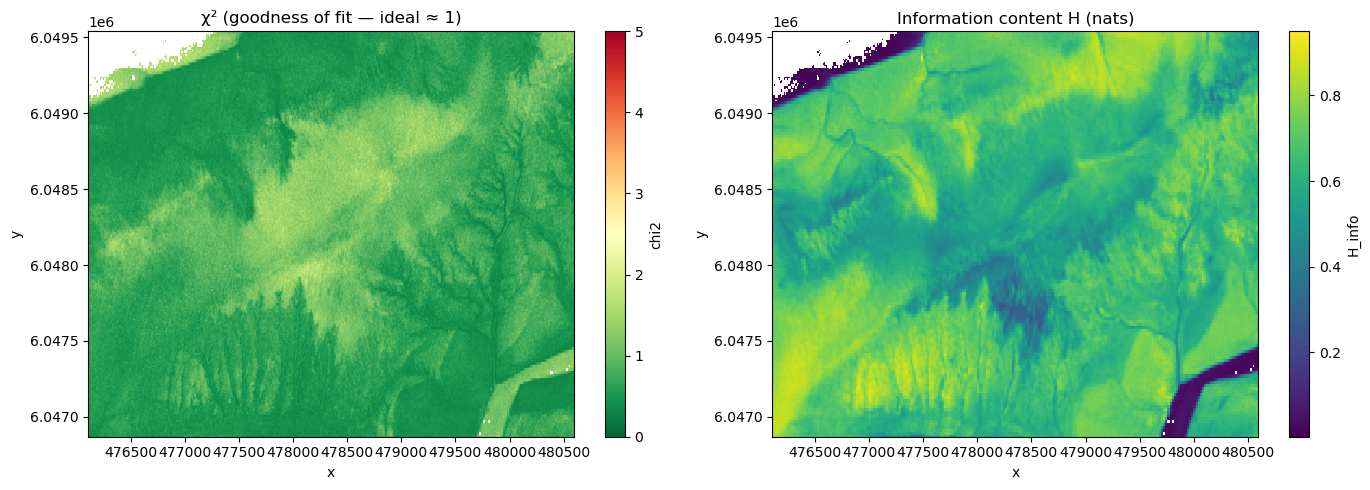

Median χ²:     0.64
Pixels χ² > 3: 0 / 119883
Median H_info: 0.6550 nats


In [9]:
chi2_all   = results['chi2']
H_info_all = results['H_info']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ds['chi2'].plot(ax=axes[0], vmin=0, vmax=5, cmap='RdYlGn_r')
axes[0].set_title('χ² (goodness of fit — ideal ≈ 1)')
ds['H_info'].plot(ax=axes[1], cmap='viridis')
axes[1].set_title('Information content H (nats)')
plt.tight_layout()
plt.show()

print(f'Median χ²:     {float(np.nanmedian(chi2_all)):.2f}')
print(f'Pixels χ² > 3: {(chi2_all > 3).sum()} / {chi2_all.size}')
print(f'Median H_info: {float(np.nanmedian(H_info_all)):.4f} nats')

## Retrieved parameters

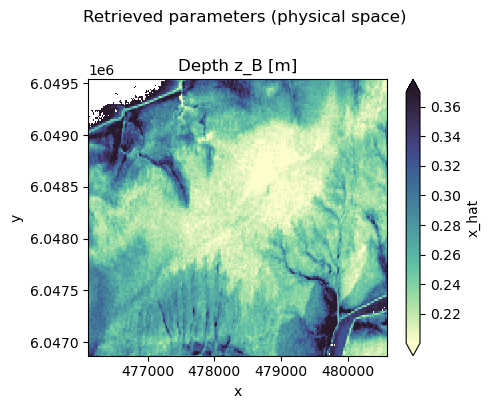

In [10]:
n_fit = len(param_labels)
fig, axes = plt.subplots(1, n_fit, figsize=(5 * n_fit, 4)) if n_fit > 1 else plt.subplots(1, 1, figsize=(5, 4))
axes = np.atleast_1d(axes)

for ax, (param, (label, unit, cmap)) in zip(axes, param_labels.items()):
    ds['x_hat'].sel(param=param).plot(ax=ax, cmap=cmap, robust=True)
    ax.set_title(f'{label} [{unit}]')

plt.suptitle('Retrieved parameters (physical space)', y=1.01)
plt.tight_layout()
plt.show()

## Posterior uncertainty — σ

σ is the posterior standard deviation in **physical space** (delta-method for log-params).  
Compare σ to the prior to see how much the data constrained each parameter.

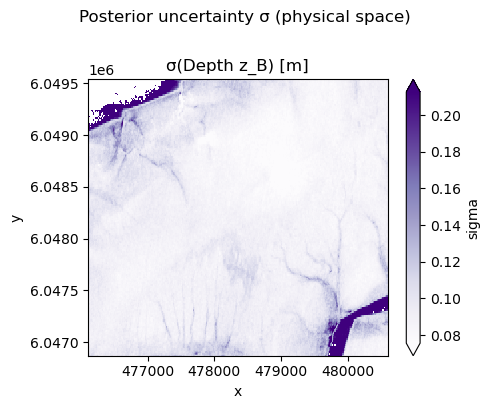

In [11]:
fig, axes = plt.subplots(1, n_fit, figsize=(5 * n_fit, 4)) if n_fit > 1 else plt.subplots(1, 1, figsize=(5, 4))
axes = np.atleast_1d(axes)

for ax, (param, (label, unit, _)) in zip(axes, param_labels.items()):
    ds['sigma'].sel(param=param).plot(ax=ax, cmap='Purples', robust=True)
    ax.set_title(f'σ({label}) [{unit}]')

plt.suptitle('Posterior uncertainty σ (physical space)', y=1.01)
plt.tight_layout()
plt.show()

## Averaging kernel diagonal — A

A[i,i] ∈ [0, 1]: fraction of the retrieved value that comes from the data
(vs. the prior).  A ≈ 1 = fully data-driven; A ≈ 0 = mostly prior.

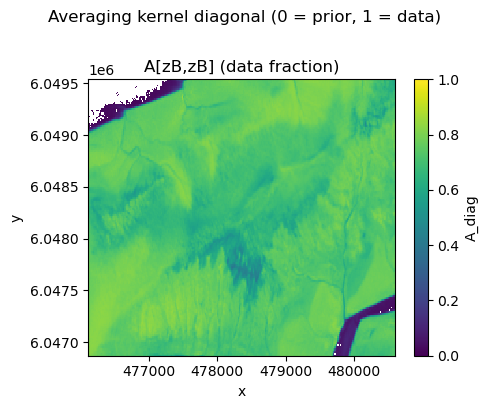

Median DFS: 0.73 / 1 parameters


In [12]:
fig, axes = plt.subplots(1, n_fit, figsize=(5 * n_fit, 4)) if n_fit > 1 else plt.subplots(1, 1, figsize=(5, 4))
axes = np.atleast_1d(axes)

for ax, (param, (label, _, __)) in zip(axes, param_labels.items()):
    ds['A_diag'].sel(param=param).plot(ax=ax, cmap='viridis', vmin=0, vmax=1)
    ax.set_title(f'A[{param},{param}] (data fraction)')

plt.suptitle('Averaging kernel diagonal (0 = prior, 1 = data)', y=1.01)
plt.tight_layout()
plt.show()

A_diag_all = results['A_diag']
dfs = A_diag_all.sum(axis=-1)
print(f'Median DFS: {np.nanmedian(dfs):.2f} / {len(setup.fit_names)} parameters')

## Per-parameter summary

In [13]:
x_hat_all  = results['x_hat']
sigma_all  = results['sigma']
A_diag_all = results['A_diag']
H_info_all = results['H_info']

header = f"{'Parameter':<10}  {'median x_hat':>12}  {'median sigma':>12}  {'median A[i,i]':>13}"
print(header)
print('-' * len(header))
for i, name in enumerate(setup.fit_names):
    x_med = np.nanmedian(x_hat_all[..., i])
    s_med = np.nanmedian(sigma_all[..., i])
    a_med = np.nanmedian(A_diag_all[..., i])
    print(f'{name:<10}  {x_med:>12.4f}  {s_med:>12.4f}  {a_med:>13.3f}')

print(f'\nMedian H_info: {float(np.nanmedian(H_info_all)):.4f} nats  '
      f'(scene-level information content)')

Parameter   median x_hat  median sigma  median A[i,i]
-----------------------------------------------------
zB                0.2480        0.0895          0.730

Median H_info: 0.6550 nats  (scene-level information content)
